# Tahap 12 — Tuning Sederhana dan Finalisasi Model Sentimen

Notebook ini merupakan kelanjutan dari tahap model improvement pada project:

**Analisis Sentimen Komentar YouTube terhadap Isu Pelemahan Nilai Rupiah dan Dampaknya terhadap Persepsi Daya Beli Masyarakat Menggunakan Python, Jupyter Notebook, GitHub, dan Streamlit.**

Pada tahap sebelumnya, model **TF-IDF + LinearSVC** menjadi kandidat model terbaik sementara berdasarkan nilai F1 Macro tertinggi. Selain itu, model **TF-IDF + Logistic Regression Balanced** juga menunjukkan performa yang kuat, terutama pada Recall Macro.

Tahap ini berfokus pada tuning sederhana terhadap kombinasi parameter TF-IDF dan parameter model klasifikasi untuk menentukan model final yang paling layak digunakan pada tahap berikutnya.

## 1. Tujuan Tahap

Tujuan dari tahap ini adalah:

1. Membaca dataset modeling terbaru dari folder `data/modeling/` secara aman.
2. Melakukan validasi kolom fitur teks dan target sentimen.
3. Melakukan tuning sederhana terhadap model **LinearSVC** sebagai kandidat utama model final.
4. Menjadikan **Logistic Regression Balanced** sebagai model pembanding.
5. Tetap menggunakan **TF-IDF** sebagai metode feature extraction.
6. Mengevaluasi model menggunakan metrik klasifikasi yang konsisten dengan tahap sebelumnya.
7. Membandingkan hasil tuning dengan performa model pada Tahap 11.
8. Menentukan model final berdasarkan prioritas:
   - F1 Macro
   - Recall Macro
   - Performa kelas `negatif` dan `positif`
   - F1 Weighted
9. Menyusun ringkasan hasil finalisasi model secara akademik dan aman untuk dokumentasi project.

## 2. Output yang Dihasilkan

Output yang diharapkan dari notebook ini adalah:

1. Informasi dataset modeling terbaru yang digunakan.
2. Validasi struktur dataset modeling.
3. Distribusi target sentimen.
4. Hasil tuning sederhana untuk:
   - TF-IDF + LinearSVC
   - TF-IDF + Logistic Regression Balanced
5. Tabel evaluasi model yang berisi:
   - Accuracy
   - Precision Macro
   - Recall Macro
   - F1-Score Macro
   - Precision Weighted
   - Recall Weighted
   - F1-Score Weighted
6. Classification report untuk model terbaik.
7. Confusion matrix untuk model terbaik.
8. Visualisasi perbandingan metrik secara agregat.
9. Laporan ringkasan finalisasi model di folder `reports/`.
10. Checklist keamanan sebelum file notebook dan laporan dipush ke GitHub.

Catatan penting:

Dataset komentar penuh dan artifact model yang memuat vocabulary TF-IDF tidak akan dipublikasikan ke GitHub.

## 3. Konsep Tuning Sederhana

Tuning sederhana adalah proses mencoba beberapa kombinasi parameter model untuk melihat konfigurasi mana yang menghasilkan performa paling baik.

Pada tahap ini, tuning dilakukan secara terbatas agar proses tetap ringan, mudah dipahami, dan sesuai dengan kebutuhan project akademik.

Parameter yang diuji meliputi:

### 3.1 Parameter TF-IDF

1. `ngram_range`
   - `(1, 1)` berarti model hanya menggunakan unigram atau kata tunggal.
   - `(1, 2)` berarti model menggunakan unigram dan bigram, sehingga dapat menangkap frasa pendek.

2. `min_df`
   - Menentukan batas minimum kemunculan kata dalam dokumen.
   - Nilai yang digunakan: `2` dan `3`.

3. `max_df`
   - Menentukan batas maksimum proporsi dokumen yang mengandung suatu kata.
   - Kata yang terlalu sering muncul dapat dianggap kurang informatif.
   - Nilai yang digunakan: `0.90` dan `0.95`.

### 3.2 Parameter Model

1. `C` pada LinearSVC dan Logistic Regression
   - Parameter `C` mengatur kekuatan regularisasi.
   - Nilai `C` kecil membuat model lebih sederhana.
   - Nilai `C` besar membuat model lebih menyesuaikan data training.

### 3.3 Alasan Tidak Menggunakan Banyak Algoritma Baru

Tahap ini tidak menambahkan banyak algoritma baru karena tujuan utamanya adalah melakukan penyempurnaan terhadap model yang sudah terbukti kuat pada Tahap 11, yaitu LinearSVC dan Logistic Regression Balanced.

Dengan demikian, proses analisis tetap fokus, terukur, dan mudah dijelaskan secara akademik.

In [1]:
# ============================================================
# Tahap 12 - Import Library
# ============================================================

import os
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# Pengaturan tampilan agar output tidak terlalu panjang
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)

# Konstanta eksperimen
RANDOM_STATE = 42
TEST_SIZE = 0.20

print("Library berhasil diimport.")
print("Random state:", RANDOM_STATE)
print("Test size:", TEST_SIZE)

Library berhasil diimport.
Random state: 42
Test size: 0.2


In [2]:
# ============================================================
# Deteksi Project Root
# ============================================================

def find_project_root(start_path=None):
    """
    Mendeteksi folder root project berdasarkan keberadaan folder utama:
    notebooks, data, dan reports.

    Fungsi ini dibuat agar notebook tetap dapat dijalankan dari folder notebooks
    maupun dari root project.
    """
    if start_path is None:
        start_path = Path.cwd()

    start_path = Path(start_path).resolve()

    for path in [start_path] + list(start_path.parents):
        has_notebooks = (path / "notebooks").exists()
        has_data = (path / "data").exists()
        has_reports = (path / "reports").exists()

        if has_notebooks and has_data and has_reports:
            return path

    raise FileNotFoundError(
        "Project root tidak ditemukan. Pastikan folder 'notebooks', 'data', dan 'reports' tersedia."
    )


PROJECT_ROOT = find_project_root()

DATA_MODELING_DIR = PROJECT_ROOT / "data" / "modeling"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
METADATA_DIR = REPORTS_DIR / "metadata"

# Membuat folder output laporan/visualisasi jika belum ada
REPORTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)
METADATA_DIR.mkdir(exist_ok=True)

print("Project root berhasil terdeteksi:")
print(PROJECT_ROOT)

print("\nFolder dataset modeling:")
print(DATA_MODELING_DIR)

print("\nFolder reports:")
print(REPORTS_DIR)

Project root berhasil terdeteksi:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis

Folder dataset modeling:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\modeling

Folder reports:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports


In [3]:
# ============================================================
# Validasi Folder Dataset Modeling
# ============================================================

if not DATA_MODELING_DIR.exists():
    raise FileNotFoundError(
        f"Folder data/modeling tidak ditemukan: {DATA_MODELING_DIR}"
    )

print("Folder data/modeling ditemukan.")

Folder data/modeling ditemukan.


In [4]:
# ============================================================
# Deteksi Dataset Modeling Terbaru
# ============================================================

allowed_patterns = ["*.csv", "*.xlsx", "*.parquet"]

dataset_files = []

for pattern in allowed_patterns:
    dataset_files.extend(DATA_MODELING_DIR.glob(pattern))

# Hindari file sementara, backup, atau file sistem
dataset_files = [
    file for file in dataset_files
    if not file.name.startswith("~$")
    and "backup" not in file.name.lower()
    and file.is_file()
]

if len(dataset_files) == 0:
    raise FileNotFoundError(
        f"Tidak ada file dataset modeling ditemukan di folder: {DATA_MODELING_DIR}"
    )

latest_dataset_file = max(dataset_files, key=lambda file: file.stat().st_mtime)

modified_time = datetime.fromtimestamp(latest_dataset_file.stat().st_mtime)
file_size_mb = latest_dataset_file.stat().st_size / (1024 * 1024)

print("Dataset modeling terbaru berhasil ditemukan.")
print("Nama file:", latest_dataset_file.name)
print("Lokasi:", latest_dataset_file)
print("Waktu modifikasi:", modified_time.strftime("%Y-%m-%d %H:%M:%S"))
print(f"Ukuran file: {file_size_mb:.2f} MB")

Dataset modeling terbaru berhasil ditemukan.
Nama file: youtube_comments_modeling_ready_20260529_171713.csv
Lokasi: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\modeling\youtube_comments_modeling_ready_20260529_171713.csv
Waktu modifikasi: 2026-05-29 17:17:13
Ukuran file: 0.41 MB


In [5]:
# ============================================================
# Load Dataset Modeling Secara Aman
# ============================================================

def load_modeling_dataset(file_path):
    """
    Membaca dataset modeling berdasarkan ekstensi file.
    Fungsi ini hanya membaca dataset dari data/modeling dan tidak membaca .env.
    """
    file_path = Path(file_path)

    if file_path.suffix.lower() == ".csv":
        return pd.read_csv(file_path)

    elif file_path.suffix.lower() == ".xlsx":
        return pd.read_excel(file_path)

    elif file_path.suffix.lower() == ".parquet":
        return pd.read_parquet(file_path)

    else:
        raise ValueError(f"Format file belum didukung: {file_path.suffix}")


df_modeling = load_modeling_dataset(latest_dataset_file)

print("Dataset modeling berhasil dibaca.")
print("Jumlah baris:", df_modeling.shape[0])
print("Jumlah kolom:", df_modeling.shape[1])

Dataset modeling berhasil dibaca.
Jumlah baris: 3661
Jumlah kolom: 2


In [6]:
# ============================================================
# Tampilkan Struktur Kolom Secara Aman
# ============================================================

# Daftar kolom sensitif yang tidak akan ditampilkan
SENSITIVE_COLUMNS = {
    "author",
    "author_name",
    "channel_id",
    "user_id",
    "profile_image_url",
    "email",
    "api_key",
    "youtube_api_key"
}

safe_columns = [
    col for col in df_modeling.columns
    if col.lower() not in SENSITIVE_COLUMNS
]

column_info = pd.DataFrame({
    "nama_kolom": safe_columns,
    "tipe_data": [df_modeling[col].dtype for col in safe_columns],
    "jumlah_null": [df_modeling[col].isna().sum() for col in safe_columns]
})

print("Struktur kolom aman berhasil disiapkan.")
display(column_info)

Struktur kolom aman berhasil disiapkan.


,nama_kolom,tipe_data,jumlah_null
0,text_clean,str,0
1,sentiment_label,str,0


In [7]:
# ============================================================
# Deteksi Kolom Fitur dan Target
# ============================================================

TEXT_COLUMN_CANDIDATES = [
    "text_modeling",
    "text_preprocessed",
    "text_clean",
    "clean_text",
    "cleaned_text",
    "text_stemmed",
    "text_normalized",
    "comment_cleaned",
    "final_text",
    "text"
]

TARGET_COLUMN_CANDIDATES = [
    "sentiment_label",
    "sentiment",
    "label",
    "target",
    "pseudo_label",
    "sentiment_pseudo_label"
]


def find_existing_column(df, candidates):
    """
    Mencari nama kolom pertama yang tersedia berdasarkan daftar kandidat.
    Pencarian dibuat case-insensitive.
    """
    lower_to_original = {col.lower(): col for col in df.columns}

    for candidate in candidates:
        if candidate.lower() in lower_to_original:
            return lower_to_original[candidate.lower()]

    return None


TEXT_COL = find_existing_column(df_modeling, TEXT_COLUMN_CANDIDATES)
TARGET_COL = find_existing_column(df_modeling, TARGET_COLUMN_CANDIDATES)

if TEXT_COL is None:
    raise ValueError(
        "Kolom fitur teks tidak ditemukan. "
        "Silakan cek kembali nama kolom teks pada dataset modeling."
    )

if TARGET_COL is None:
    raise ValueError(
        "Kolom target sentimen tidak ditemukan. "
        "Silakan cek kembali nama kolom label pada dataset modeling."
    )

print("Kolom fitur dan target berhasil terdeteksi.")
print("Kolom fitur teks:", TEXT_COL)
print("Kolom target:", TARGET_COL)

Kolom fitur dan target berhasil terdeteksi.
Kolom fitur teks: text_clean
Kolom target: sentiment_label


In [8]:
# ============================================================
# Validasi Dataset untuk Modeling
# ============================================================

df_work = df_modeling[[TEXT_COL, TARGET_COL]].copy()

# Pastikan tipe data berupa string
df_work[TEXT_COL] = df_work[TEXT_COL].astype(str)
df_work[TARGET_COL] = df_work[TARGET_COL].astype(str)

# Normalisasi ringan pada target
df_work[TEXT_COL] = df_work[TEXT_COL].str.strip()
df_work[TARGET_COL] = df_work[TARGET_COL].str.strip().str.lower()

initial_rows = len(df_work)

# Hapus baris yang kosong pada fitur atau target
df_work = df_work.replace({"": np.nan})
df_work = df_work.dropna(subset=[TEXT_COL, TARGET_COL])

final_rows = len(df_work)
removed_rows = initial_rows - final_rows

print("Validasi awal dataset selesai.")
print("Jumlah baris awal:", initial_rows)
print("Jumlah baris setelah validasi:", final_rows)
print("Jumlah baris terhapus karena kosong/null:", removed_rows)

Validasi awal dataset selesai.
Jumlah baris awal: 3661
Jumlah baris setelah validasi: 3661
Jumlah baris terhapus karena kosong/null: 0


In [9]:
# ============================================================
# Validasi Label Sentimen
# ============================================================

expected_labels = {"negatif", "netral", "positif"}
actual_labels = set(df_work[TARGET_COL].unique())

unexpected_labels = actual_labels - expected_labels
missing_labels = expected_labels - actual_labels

print("Label ditemukan:", sorted(actual_labels))

if unexpected_labels:
    print("\nPeringatan: terdapat label di luar label yang diharapkan:")
    print(sorted(unexpected_labels))

if missing_labels:
    print("\nPeringatan: terdapat label yang belum muncul di dataset:")
    print(sorted(missing_labels))

if not unexpected_labels and not missing_labels:
    print("\nValidasi label berhasil. Label sesuai dengan skema: negatif, netral, positif.")

Label ditemukan: ['negatif', 'netral', 'positif']

Validasi label berhasil. Label sesuai dengan skema: negatif, netral, positif.


In [10]:
# ============================================================
# Distribusi Target Sentimen
# ============================================================

label_distribution = (
    df_work[TARGET_COL]
    .value_counts()
    .rename_axis("label_sentimen")
    .reset_index(name="jumlah")
)

label_distribution["persentase"] = (
    label_distribution["jumlah"] / label_distribution["jumlah"].sum() * 100
).round(2)

print("Distribusi label sentimen:")
display(label_distribution)

Distribusi label sentimen:


,label_sentimen,jumlah,persentase
0,netral,2416,65.99
1,negatif,637,17.40
2,positif,608,16.61


In [11]:
# ============================================================
# Sampel Aman Dataset
# ============================================================

SHOW_SAFE_SAMPLE = False

def truncate_text(text, max_length=120):
    """
    Memotong teks agar tidak menampilkan komentar secara penuh.
    """
    text = str(text)

    if len(text) > max_length:
        return text[:max_length] + "..."

    return text


if SHOW_SAFE_SAMPLE:
    sample_size = min(5, len(df_work))

    df_sample_safe = (
        df_work[[TEXT_COL, TARGET_COL]]
        .sample(n=sample_size, random_state=RANDOM_STATE)
        .copy()
    )

    df_sample_safe[TEXT_COL] = df_sample_safe[TEXT_COL].apply(truncate_text)

    df_sample_safe = df_sample_safe.rename(columns={
        TEXT_COL: "teks_aman_dipotong",
        TARGET_COL: "label_sentimen"
    })

    display(df_sample_safe)
else:
    print("Sampel komentar tidak ditampilkan.")
    print("Untuk audit terbatas, ubah SHOW_SAFE_SAMPLE menjadi True.")

Sampel komentar tidak ditampilkan.
Untuk audit terbatas, ubah SHOW_SAFE_SAMPLE menjadi True.


In [12]:
# ============================================================
# Ringkasan Kesiapan Dataset
# ============================================================

dataset_readiness_summary = {
    "dataset_file": latest_dataset_file.name,
    "total_rows_after_validation": int(len(df_work)),
    "text_column": TEXT_COL,
    "target_column": TARGET_COL,
    "labels": sorted(list(actual_labels)),
    "ready_for_train_test_split": True if len(df_work) > 0 else False,
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE
}

print("Ringkasan kesiapan dataset:")
print(json.dumps(dataset_readiness_summary, indent=4, ensure_ascii=False))

Ringkasan kesiapan dataset:
{
    "dataset_file": "youtube_comments_modeling_ready_20260529_171713.csv",
    "total_rows_after_validation": 3661,
    "text_column": "text_clean",
    "target_column": "sentiment_label",
    "labels": [
        "negatif",
        "netral",
        "positif"
    ],
    "ready_for_train_test_split": true,
    "random_state": 42,
    "test_size": 0.2
}


## 4. Train-test Split Konsisten dengan Tahap Sebelumnya

Pada tahap ini, dataset dibagi menjadi data latih dan data uji menggunakan skema yang konsisten dengan tahap sebelumnya.

Konfigurasi yang digunakan adalah:

- `test_size = 0.20`
- `random_state = 42`
- `stratify = y`

Penggunaan `stratify=y` bertujuan agar distribusi kelas sentimen pada data latih dan data uji tetap seimbang secara proporsional. Hal ini penting karena dataset sentimen memiliki lebih dari satu kelas, yaitu `negatif`, `netral`, dan `positif`.

Data latih akan digunakan dalam proses training dan tuning model, sedangkan data uji tetap digunakan sebagai data evaluasi akhir agar pengukuran performa model lebih objektif.

In [13]:
# ============================================================
# Menyiapkan Fitur dan Target
# ============================================================

X = df_work[TEXT_COL].copy()
y = df_work[TARGET_COL].copy()

print("Fitur dan target berhasil disiapkan.")
print("Jumlah data X:", X.shape[0])
print("Jumlah data y:", y.shape[0])

print("\nKolom fitur teks:", TEXT_COL)
print("Kolom target:", TARGET_COL)

Fitur dan target berhasil disiapkan.
Jumlah data X: 3661
Jumlah data y: 3661

Kolom fitur teks: text_clean
Kolom target: sentiment_label


In [14]:
# ============================================================
# Validasi Jumlah Data per Kelas Sebelum Train-test Split
# ============================================================

class_counts_before_split = y.value_counts().sort_index()

print("Distribusi kelas sebelum train-test split:")
display(
    class_counts_before_split
    .rename_axis("label_sentimen")
    .reset_index(name="jumlah")
)

min_class_count = class_counts_before_split.min()

if min_class_count < 2:
    raise ValueError(
        "Train-test split dengan stratify tidak dapat dilakukan karena "
        "terdapat kelas dengan jumlah data kurang dari 2."
    )

print("\nValidasi berhasil.")
print("Jumlah minimum data pada satu kelas:", min_class_count)
print("Dataset layak untuk train-test split dengan stratify.")

Distribusi kelas sebelum train-test split:


,label_sentimen,jumlah
0,negatif,637
1,netral,2416
2,positif,608



Validasi berhasil.
Jumlah minimum data pada satu kelas: 608
Dataset layak untuk train-test split dengan stratify.


In [15]:
# ============================================================
# Train-test Split Konsisten
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train-test split berhasil dilakukan.")
print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

print("\nKonfigurasi split:")
print("Test size:", TEST_SIZE)
print("Random state:", RANDOM_STATE)
print("Stratify:", True)

Train-test split berhasil dilakukan.
Jumlah data training: 2928
Jumlah data testing: 733

Konfigurasi split:
Test size: 0.2
Random state: 42
Stratify: True


In [16]:
# ============================================================
# Validasi Distribusi Label Setelah Split
# ============================================================

def build_label_distribution(y_series, split_name):
    """
    Membuat tabel distribusi label untuk setiap subset data.
    Output hanya berupa agregat jumlah dan persentase, tanpa menampilkan teks komentar.
    """
    distribution = (
        y_series
        .value_counts()
        .sort_index()
        .rename_axis("label_sentimen")
        .reset_index(name="jumlah")
    )

    distribution["persentase"] = (
        distribution["jumlah"] / distribution["jumlah"].sum() * 100
    ).round(2)

    distribution.insert(0, "split", split_name)

    return distribution


df_distribution_full = build_label_distribution(y, "full_dataset")
df_distribution_train = build_label_distribution(y_train, "train")
df_distribution_test = build_label_distribution(y_test, "test")

df_split_distribution = pd.concat(
    [
        df_distribution_full,
        df_distribution_train,
        df_distribution_test
    ],
    ignore_index=True
)

print("Distribusi label pada full dataset, train set, dan test set:")
display(df_split_distribution)

Distribusi label pada full dataset, train set, dan test set:


,split,label_sentimen,jumlah,persentase
0,full_dataset,negatif,637,17.40
1,full_dataset,netral,2416,65.99
2,full_dataset,positif,608,16.61
3,train,negatif,510,17.42
4,train,netral,1932,65.98
5,train,positif,486,16.60
6,test,negatif,127,17.33
7,test,netral,484,66.03
8,test,positif,122,16.64


In [17]:
# ============================================================
# Perbandingan Proporsi Label Antar Split
# ============================================================

df_split_percentage_comparison = (
    df_split_distribution
    .pivot(index="label_sentimen", columns="split", values="persentase")
    .reset_index()
)

# Hitung selisih proporsi terhadap full dataset
if "full_dataset" in df_split_percentage_comparison.columns:
    if "train" in df_split_percentage_comparison.columns:
        df_split_percentage_comparison["selisih_train_vs_full"] = (
            df_split_percentage_comparison["train"] 
            - df_split_percentage_comparison["full_dataset"]
        ).round(2)

    if "test" in df_split_percentage_comparison.columns:
        df_split_percentage_comparison["selisih_test_vs_full"] = (
            df_split_percentage_comparison["test"] 
            - df_split_percentage_comparison["full_dataset"]
        ).round(2)

print("Perbandingan proporsi label antar split:")
display(df_split_percentage_comparison)

Perbandingan proporsi label antar split:


split,label_sentimen,full_dataset,test,train,selisih_train_vs_full,selisih_test_vs_full
0,negatif,17.40,17.33,17.42,0.02,-0.07
1,netral,65.99,66.03,65.98,-0.01,0.04
2,positif,16.61,16.64,16.60,-0.01,0.03


In [18]:
# ============================================================
# Cek Potensi Duplikasi Teks antara Train dan Test
# ============================================================

train_text_set = set(X_train.astype(str))
test_text_set = set(X_test.astype(str))

overlap_text_count = len(train_text_set.intersection(test_text_set))

print("Cek potensi overlap teks antara train set dan test set:")
print("Jumlah teks unik di train set:", len(train_text_set))
print("Jumlah teks unik di test set:", len(test_text_set))
print("Jumlah teks yang muncul di train dan test:", overlap_text_count)

if overlap_text_count > 0:
    print("\nPeringatan:")
    print(
        "Terdapat teks yang muncul di train set dan test set. "
        "Hal ini dapat terjadi jika ada komentar duplikat pada dataset. "
        "Untuk menjaga konsistensi dengan tahap sebelumnya, data tidak diubah pada tahap ini."
    )
else:
    print("\nTidak ditemukan overlap teks antara train set dan test set.")

Cek potensi overlap teks antara train set dan test set:
Jumlah teks unik di train set: 2928
Jumlah teks unik di test set: 733
Jumlah teks yang muncul di train dan test: 0

Tidak ditemukan overlap teks antara train set dan test set.


In [19]:
# ============================================================
# Simpan Metadata Train-test Split Secara Aman
# ============================================================

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

split_metadata = {
    "stage": "12_model_tuning_and_finalization",
    "dataset_file": latest_dataset_file.name,
    "text_column": TEXT_COL,
    "target_column": TARGET_COL,
    "total_rows": int(len(y)),
    "train_rows": int(len(y_train)),
    "test_rows": int(len(y_test)),
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "stratify": True,
    "label_distribution": df_split_distribution.to_dict(orient="records"),
    "overlap_text_count_between_train_test": int(overlap_text_count),
    "created_at": timestamp
}

split_metadata_path = METADATA_DIR / f"stage_12_train_test_split_metadata_{timestamp}.json"

with open(split_metadata_path, "w", encoding="utf-8") as f:
    json.dump(split_metadata, f, indent=4, ensure_ascii=False)

print("Metadata train-test split berhasil disimpan secara aman.")
print("Lokasi file:")
print(split_metadata_path)

Metadata train-test split berhasil disimpan secara aman.
Lokasi file:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\metadata\stage_12_train_test_split_metadata_20260531_000426.json


## 5. Interpretasi Awal Train-test Split

Train-test split telah dilakukan dengan pendekatan stratified sampling. Dengan pendekatan ini, proporsi label sentimen pada data latih dan data uji tetap dijaga agar mendekati distribusi label pada dataset penuh.

Data latih akan digunakan untuk proses tuning model menggunakan kombinasi TF-IDF dan algoritma klasifikasi. Data uji tidak digunakan dalam proses training, melainkan hanya digunakan untuk evaluasi performa model.

Dengan demikian, hasil evaluasi pada data uji diharapkan dapat memberikan gambaran performa model yang lebih objektif terhadap data baru.

## 6. Tuning Sederhana untuk LinearSVC

Pada tahap sebelumnya, model **TF-IDF + LinearSVC** menjadi kandidat model terbaik sementara karena memperoleh nilai F1 Macro tertinggi dibandingkan model lain.

Pada tahap ini, LinearSVC akan dituning secara sederhana menggunakan beberapa kombinasi parameter TF-IDF dan parameter model.

Parameter yang diuji meliputi:

### Parameter TF-IDF

- `ngram_range`: `(1, 1)` dan `(1, 2)`
- `min_df`: `2` dan `3`
- `max_df`: `0.90` dan `0.95`

### Parameter LinearSVC

- `C`: `0.5`, `1.0`, dan `2.0`

Proses tuning dilakukan menggunakan `GridSearchCV` dengan scoring utama `f1_macro`.

Pemilihan `f1_macro` sebagai metrik utama bertujuan agar model tidak hanya baik pada kelas mayoritas, tetapi juga memperhatikan performa pada seluruh kelas sentimen secara lebih seimbang.

In [20]:
# ============================================================
# Fungsi Evaluasi Model Klasifikasi
# ============================================================

SENTIMENT_LABEL_ORDER = ["negatif", "netral", "positif"]

# Gunakan hanya label yang benar-benar tersedia pada data uji
available_label_order = [
    label for label in SENTIMENT_LABEL_ORDER
    if label in sorted(y_test.unique())
]

def evaluate_model(model, X_test, y_test, model_name):
    """
    Mengevaluasi model klasifikasi sentimen menggunakan metrik utama:
    accuracy, precision macro, recall macro, f1 macro,
    precision weighted, recall weighted, dan f1 weighted.

    Fungsi ini tidak menampilkan komentar asli.
    Output hanya berupa hasil evaluasi agregat.
    """
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    metrics = {
        "model": model_name,
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }

    report_dict = classification_report(
        y_test,
        y_pred,
        labels=available_label_order,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report_dict).T

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=available_label_order
    )

    return metrics, report_df, cm, y_pred


print("Fungsi evaluasi model berhasil dibuat.")
print("Urutan label evaluasi:", available_label_order)

Fungsi evaluasi model berhasil dibuat.
Urutan label evaluasi: ['negatif', 'netral', 'positif']


In [21]:
# ============================================================
# Pipeline TF-IDF + LinearSVC
# ============================================================

linear_svc_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LinearSVC(
            class_weight="balanced",
            max_iter=10000,
            random_state=RANDOM_STATE
        )
    )
])

print("Pipeline TF-IDF + LinearSVC berhasil dibuat.")

Pipeline TF-IDF + LinearSVC berhasil dibuat.


In [22]:
# ============================================================
# Parameter Grid untuk LinearSVC
# ============================================================

linear_svc_param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [2, 3],
    "tfidf__max_df": [0.90, 0.95],
    "classifier__C": [0.5, 1.0, 2.0]
}

total_combinations = (
    len(linear_svc_param_grid["tfidf__ngram_range"])
    * len(linear_svc_param_grid["tfidf__min_df"])
    * len(linear_svc_param_grid["tfidf__max_df"])
    * len(linear_svc_param_grid["classifier__C"])
)

print("Parameter grid LinearSVC berhasil disiapkan.")
print("Total kombinasi parameter:", total_combinations)

Parameter grid LinearSVC berhasil disiapkan.
Total kombinasi parameter: 24


In [23]:
# ============================================================
# Konfigurasi Cross Validation
# ============================================================

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("Strategi cross validation berhasil disiapkan.")
print("Jumlah fold:", cv_strategy.get_n_splits())
print("Shuffle:", True)
print("Random state:", RANDOM_STATE)

Strategi cross validation berhasil disiapkan.
Jumlah fold: 5
Shuffle: True
Random state: 42


In [24]:
# ============================================================
# Tuning LinearSVC dengan GridSearchCV
# ============================================================

linear_svc_grid_search = GridSearchCV(
    estimator=linear_svc_pipeline,
    param_grid=linear_svc_param_grid,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Proses tuning LinearSVC dimulai...")

linear_svc_grid_search.fit(X_train, y_train)

print("\nProses tuning LinearSVC selesai.")
print("Best score CV F1 Macro:", round(linear_svc_grid_search.best_score_, 4))
print("Best parameters:")
print(linear_svc_grid_search.best_params_)

Proses tuning LinearSVC dimulai...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Proses tuning LinearSVC selesai.
Best score CV F1 Macro: 0.8374
Best parameters:
{'classifier__C': 0.5, 'tfidf__max_df': 0.9, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 1)}


In [25]:
# ============================================================
# Top 10 Hasil Tuning LinearSVC
# ============================================================

df_linear_svc_cv_results = pd.DataFrame(linear_svc_grid_search.cv_results_)

selected_cv_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "param_tfidf__ngram_range",
    "param_tfidf__min_df",
    "param_tfidf__max_df",
    "param_classifier__C"
]

df_linear_svc_top10 = (
    df_linear_svc_cv_results[selected_cv_columns]
    .sort_values(by="rank_test_score")
    .head(10)
    .copy()
)

# Pembulatan agar tabel lebih mudah dibaca
score_columns = [
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score"
]

df_linear_svc_top10[score_columns] = df_linear_svc_top10[score_columns].round(4)

print("Top 10 kombinasi parameter LinearSVC berdasarkan F1 Macro CV:")
display(df_linear_svc_top10)

Top 10 kombinasi parameter LinearSVC berdasarkan F1 Macro CV:


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,param_tfidf__ngram_range,param_tfidf__min_df,param_tfidf__max_df,param_classifier__C
2,1,0.8374,0.0105,0.9758,0.0025,"(1, 1)",3,0.90,0.5
6,1,0.8374,0.0105,0.9758,0.0025,"(1, 1)",3,0.95,0.5
12,3,0.8364,0.0100,0.9900,0.0013,"(1, 1)",2,0.95,1.0
8,3,0.8364,0.0100,0.9900,0.0013,"(1, 1)",2,0.90,1.0
10,5,0.8357,0.0076,0.9847,0.0014,"(1, 1)",3,0.90,1.0
14,5,0.8357,0.0076,0.9847,0.0014,"(1, 1)",3,0.95,1.0
4,7,0.8355,0.0130,0.9807,0.0012,"(1, 1)",2,0.95,0.5
0,7,0.8355,0.0130,0.9807,0.0012,"(1, 1)",2,0.90,0.5
20,9,0.8336,0.0098,0.9944,0.0007,"(1, 1)",2,0.95,2.0
16,9,0.8336,0.0098,0.9944,0.0007,"(1, 1)",2,0.90,2.0


In [26]:
# ============================================================
# Simpan Hasil Tuning LinearSVC Secara Aman
# ============================================================

linear_svc_tuning_results_path = (
    METADATA_DIR / f"stage_12_linear_svc_tuning_results_{timestamp}.csv"
)

df_linear_svc_cv_results[selected_cv_columns].to_csv(
    linear_svc_tuning_results_path,
    index=False,
    encoding="utf-8-sig"
)

print("Hasil tuning LinearSVC berhasil disimpan secara aman.")
print("Lokasi file:")
print(linear_svc_tuning_results_path)

Hasil tuning LinearSVC berhasil disimpan secara aman.
Lokasi file:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\metadata\stage_12_linear_svc_tuning_results_20260531_000426.csv


In [27]:
# ============================================================
# Evaluasi Best LinearSVC pada Test Set
# ============================================================

best_linear_svc_model = linear_svc_grid_search.best_estimator_

linear_svc_metrics, linear_svc_report_df, linear_svc_cm, linear_svc_y_pred = evaluate_model(
    model=best_linear_svc_model,
    X_test=X_test,
    y_test=y_test,
    model_name="Tuned TF-IDF + LinearSVC"
)

df_linear_svc_metrics = pd.DataFrame([linear_svc_metrics])

metric_columns = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted"
]

df_linear_svc_metrics_rounded = df_linear_svc_metrics.copy()
df_linear_svc_metrics_rounded[metric_columns] = (
    df_linear_svc_metrics_rounded[metric_columns].round(4)
)

print("Evaluasi Best LinearSVC pada test set:")
display(df_linear_svc_metrics_rounded)

Evaluasi Best LinearSVC pada test set:


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Tuned TF-IDF + LinearSVC,0.8827,0.8667,0.8338,0.8489,0.8815,0.8827,0.8812


In [28]:
# ============================================================
# Classification Report LinearSVC
# ============================================================

linear_svc_report_display = linear_svc_report_df.copy()

numeric_cols = linear_svc_report_display.select_dtypes(include=["float64", "float32"]).columns
linear_svc_report_display[numeric_cols] = linear_svc_report_display[numeric_cols].round(4)

print("Classification Report - Tuned TF-IDF + LinearSVC:")
display(linear_svc_report_display)

Classification Report - Tuned TF-IDF + LinearSVC:


,precision,recall,f1-score,support
negatif,0.8571,0.7559,0.8033,127.0000
netral,0.8968,0.9339,0.9150,484.0000
positif,0.8462,0.8115,0.8285,122.0000
accuracy,0.8827,0.8827,0.8827,0.8827
macro avg,0.8667,0.8338,0.8489,733.0000
weighted avg,0.8815,0.8827,0.8812,733.0000


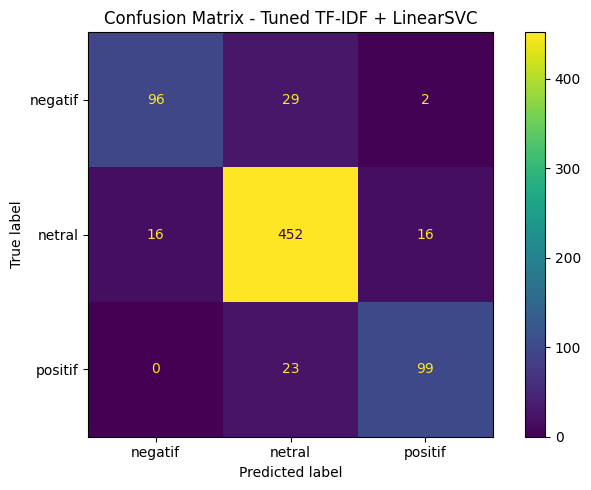

In [29]:
# ============================================================
# Confusion Matrix LinearSVC
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=linear_svc_cm,
    display_labels=available_label_order
)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Tuned TF-IDF + LinearSVC")
plt.tight_layout()
plt.show()

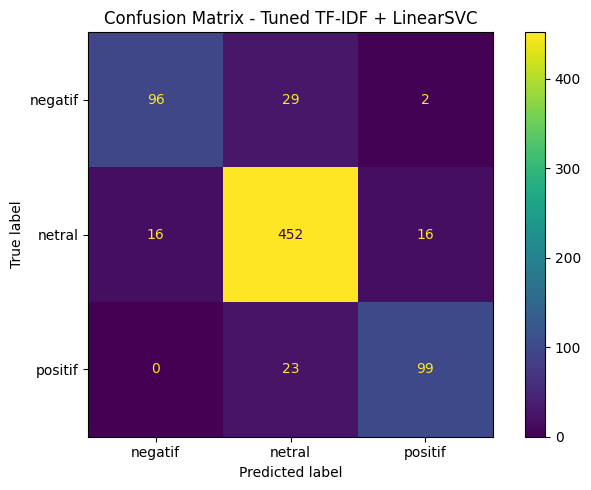

Confusion matrix LinearSVC berhasil disimpan.
Lokasi file:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\figures\stage_12_confusion_matrix_linear_svc_20260531_000426.png


In [30]:
# ============================================================
# Simpan Confusion Matrix LinearSVC
# ============================================================

linear_svc_cm_path = FIGURES_DIR / f"stage_12_confusion_matrix_linear_svc_{timestamp}.png"

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=linear_svc_cm,
    display_labels=available_label_order
)
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Tuned TF-IDF + LinearSVC")
plt.tight_layout()
plt.savefig(linear_svc_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix LinearSVC berhasil disimpan.")
print("Lokasi file:")
print(linear_svc_cm_path)

In [31]:
# ============================================================
# Ringkasan Parameter Terbaik LinearSVC
# ============================================================

linear_svc_best_summary = {
    "model": "Tuned TF-IDF + LinearSVC",
    "best_cv_f1_macro": round(float(linear_svc_grid_search.best_score_), 4),
    "best_params": linear_svc_grid_search.best_params_,
    "test_metrics": {
        key: round(float(value), 4)
        for key, value in linear_svc_metrics.items()
        if key != "model"
    }
}

print("Ringkasan best LinearSVC:")
print(json.dumps(linear_svc_best_summary, indent=4, ensure_ascii=False))

Ringkasan best LinearSVC:
{
    "model": "Tuned TF-IDF + LinearSVC",
    "best_cv_f1_macro": 0.8374,
    "best_params": {
        "classifier__C": 0.5,
        "tfidf__max_df": 0.9,
        "tfidf__min_df": 3,
        "tfidf__ngram_range": [
            1,
            1
        ]
    },
    "test_metrics": {
        "accuracy": 0.8827,
        "precision_macro": 0.8667,
        "recall_macro": 0.8338,
        "f1_macro": 0.8489,
        "precision_weighted": 0.8815,
        "recall_weighted": 0.8827,
        "f1_weighted": 0.8812
    }
}


## 7. Interpretasi Awal Hasil Tuning LinearSVC

Berdasarkan hasil tuning sederhana, model **TF-IDF + LinearSVC** dievaluasi menggunakan kombinasi parameter terbaik dari proses `GridSearchCV`.

Nilai utama yang perlu diperhatikan adalah:

1. **F1 Macro**
   - Digunakan sebagai indikator utama karena mempertimbangkan rata-rata performa seluruh kelas secara seimbang.

2. **Recall Macro**
   - Digunakan untuk melihat kemampuan model dalam menangkap data dari setiap kelas sentimen.

3. **Performa kelas negatif dan positif**
   - Penting karena dua kelas ini menunjukkan opini yang lebih eksplisit terhadap isu pelemahan rupiah dan persepsi daya beli masyarakat.

4. **F1 Weighted**
   - Digunakan sebagai indikator tambahan karena mempertimbangkan proporsi jumlah data pada setiap kelas.

Jika hasil tuning LinearSVC lebih baik atau setidaknya stabil dibandingkan hasil Tahap 11, maka LinearSVC tetap layak dipertahankan sebagai kandidat utama model final.

## 8. Tuning Sederhana Logistic Regression Balanced sebagai Pembanding

Setelah tuning LinearSVC selesai, tahap berikutnya adalah melakukan tuning sederhana terhadap model **Logistic Regression Balanced**.

Model ini digunakan sebagai pembanding karena pada Tahap 11 Logistic Regression Balanced memiliki nilai **Recall Macro** yang tinggi. Recall Macro penting karena menunjukkan kemampuan model dalam menangkap data dari setiap kelas sentimen secara seimbang.

Parameter yang diuji tetap dibuat sederhana agar proses tuning tidak terlalu kompleks.

Parameter TF-IDF yang diuji:

- `ngram_range`: `(1, 1)` dan `(1, 2)`
- `min_df`: `2` dan `3`
- `max_df`: `0.90` dan `0.95`

Parameter Logistic Regression yang diuji:

- `C`: `0.5`, `1.0`, dan `2.0`

Model menggunakan `class_weight="balanced"` agar model lebih memperhatikan kelas minoritas.

In [35]:
# ============================================================
# Pipeline TF-IDF + Logistic Regression Balanced
# ============================================================

logreg_pipeline = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            solver="lbfgs",
            max_iter=10000,
            random_state=RANDOM_STATE
        )
    )
])

print("Pipeline TF-IDF + Logistic Regression Balanced berhasil dibuat.")
print("Solver yang digunakan: lbfgs")
print("Alasan: lbfgs mendukung klasifikasi multiclass untuk label negatif, netral, dan positif.")

Pipeline TF-IDF + Logistic Regression Balanced berhasil dibuat.
Solver yang digunakan: lbfgs
Alasan: lbfgs mendukung klasifikasi multiclass untuk label negatif, netral, dan positif.


In [36]:
# ============================================================
# Parameter Grid untuk Logistic Regression Balanced
# ============================================================

logreg_param_grid = {
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "tfidf__min_df": [2, 3],
    "tfidf__max_df": [0.90, 0.95],
    "classifier__C": [0.5, 1.0, 2.0]
}

total_logreg_combinations = (
    len(logreg_param_grid["tfidf__ngram_range"])
    * len(logreg_param_grid["tfidf__min_df"])
    * len(logreg_param_grid["tfidf__max_df"])
    * len(logreg_param_grid["classifier__C"])
)

print("Parameter grid Logistic Regression berhasil disiapkan.")
print("Total kombinasi parameter:", total_logreg_combinations)

Parameter grid Logistic Regression berhasil disiapkan.
Total kombinasi parameter: 24


In [37]:
# ============================================================
# Tuning Logistic Regression Balanced dengan GridSearchCV
# ============================================================

logreg_grid_search = GridSearchCV(
    estimator=logreg_pipeline,
    param_grid=logreg_param_grid,
    scoring="f1_macro",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

print("Proses tuning Logistic Regression Balanced dimulai...")

logreg_grid_search.fit(X_train, y_train)

print("\nProses tuning Logistic Regression Balanced selesai.")
print("Best score CV F1 Macro:", round(logreg_grid_search.best_score_, 4))
print("Best parameters:")
print(logreg_grid_search.best_params_)

Proses tuning Logistic Regression Balanced dimulai...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Proses tuning Logistic Regression Balanced selesai.
Best score CV F1 Macro: 0.8303
Best parameters:
{'classifier__C': 2.0, 'tfidf__max_df': 0.9, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 1)}


In [38]:
# ============================================================
# Top 10 Hasil Tuning Logistic Regression Balanced
# ============================================================

df_logreg_cv_results = pd.DataFrame(logreg_grid_search.cv_results_)

selected_logreg_cv_columns = [
    "rank_test_score",
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score",
    "param_tfidf__ngram_range",
    "param_tfidf__min_df",
    "param_tfidf__max_df",
    "param_classifier__C"
]

df_logreg_top10 = (
    df_logreg_cv_results[selected_logreg_cv_columns]
    .sort_values(by="rank_test_score")
    .head(10)
    .copy()
)

score_columns = [
    "mean_test_score",
    "std_test_score",
    "mean_train_score",
    "std_train_score"
]

df_logreg_top10[score_columns] = df_logreg_top10[score_columns].round(4)

print("Top 10 kombinasi parameter Logistic Regression Balanced berdasarkan F1 Macro CV:")
display(df_logreg_top10)

Top 10 kombinasi parameter Logistic Regression Balanced berdasarkan F1 Macro CV:


,rank_test_score,mean_test_score,std_test_score,mean_train_score,std_train_score,param_tfidf__ngram_range,param_tfidf__min_df,param_tfidf__max_df,param_classifier__C
22,1,0.8303,0.0122,0.9609,0.0019,"(1, 1)",3,0.95,2.0
18,1,0.8303,0.0122,0.9609,0.0019,"(1, 1)",3,0.90,2.0
16,3,0.8270,0.0124,0.9646,0.0014,"(1, 1)",2,0.90,2.0
20,3,0.8270,0.0124,0.9646,0.0014,"(1, 1)",2,0.95,2.0
14,5,0.8236,0.0135,0.9451,0.0013,"(1, 1)",3,0.95,1.0
10,5,0.8236,0.0135,0.9451,0.0013,"(1, 1)",3,0.90,1.0
19,7,0.8235,0.0117,0.9665,0.0013,"(1, 2)",3,0.90,2.0
23,7,0.8235,0.0117,0.9665,0.0013,"(1, 2)",3,0.95,2.0
11,9,0.8156,0.0147,0.9514,0.0019,"(1, 2)",3,0.90,1.0
15,9,0.8156,0.0147,0.9514,0.0019,"(1, 2)",3,0.95,1.0


In [39]:
# ============================================================
# Simpan Hasil Tuning Logistic Regression Secara Aman
# ============================================================

logreg_tuning_results_path = (
    METADATA_DIR / f"stage_12_logreg_tuning_results_{timestamp}.csv"
)

df_logreg_cv_results[selected_logreg_cv_columns].to_csv(
    logreg_tuning_results_path,
    index=False,
    encoding="utf-8-sig"
)

print("Hasil tuning Logistic Regression Balanced berhasil disimpan secara aman.")
print("Lokasi file:")
print(logreg_tuning_results_path)

Hasil tuning Logistic Regression Balanced berhasil disimpan secara aman.
Lokasi file:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\metadata\stage_12_logreg_tuning_results_20260531_000426.csv


In [40]:
# ============================================================
# Evaluasi Best Logistic Regression Balanced pada Test Set
# ============================================================

best_logreg_model = logreg_grid_search.best_estimator_

logreg_metrics, logreg_report_df, logreg_cm, logreg_y_pred = evaluate_model(
    model=best_logreg_model,
    X_test=X_test,
    y_test=y_test,
    model_name="Tuned TF-IDF + Logistic Regression Balanced"
)

df_logreg_metrics = pd.DataFrame([logreg_metrics])

df_logreg_metrics_rounded = df_logreg_metrics.copy()
df_logreg_metrics_rounded[metric_columns] = (
    df_logreg_metrics_rounded[metric_columns].round(4)
)

print("Evaluasi Best Logistic Regression Balanced pada test set:")
display(df_logreg_metrics_rounded)

Evaluasi Best Logistic Regression Balanced pada test set:


,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Tuned TF-IDF + Logistic Regression Balanced,0.8881,0.8557,0.8661,0.8607,0.8893,0.8881,0.8886


In [41]:
# ============================================================
# Classification Report Logistic Regression Balanced
# ============================================================

logreg_report_display = logreg_report_df.copy()

numeric_cols = logreg_report_display.select_dtypes(include=["float64", "float32"]).columns
logreg_report_display[numeric_cols] = logreg_report_display[numeric_cols].round(4)

print("Classification Report - Tuned TF-IDF + Logistic Regression Balanced:")
display(logreg_report_display)

Classification Report - Tuned TF-IDF + Logistic Regression Balanced:


,precision,recall,f1-score,support
negatif,0.7970,0.8346,0.8154,127.0000
netral,0.9245,0.9112,0.9178,484.0000
positif,0.8455,0.8525,0.8490,122.0000
accuracy,0.8881,0.8881,0.8881,0.8881
macro avg,0.8557,0.8661,0.8607,733.0000
weighted avg,0.8893,0.8881,0.8886,733.0000


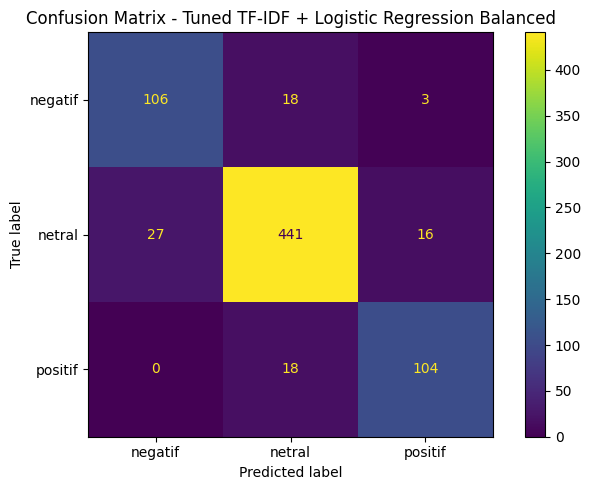

In [42]:
# ============================================================
# Confusion Matrix Logistic Regression Balanced
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=logreg_cm,
    display_labels=available_label_order
)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Tuned TF-IDF + Logistic Regression Balanced")
plt.tight_layout()
plt.show()

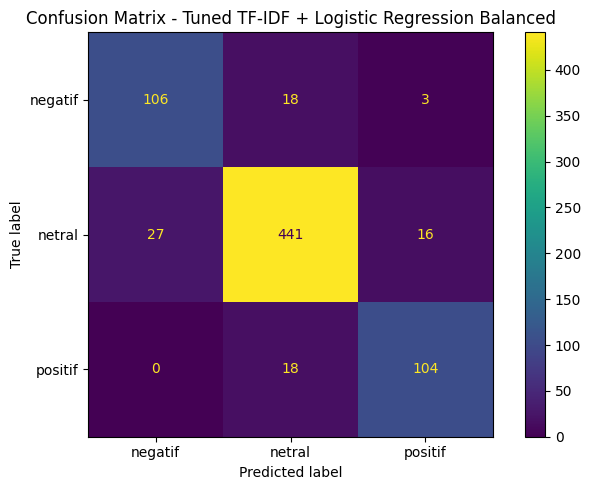

Confusion matrix Logistic Regression Balanced berhasil disimpan.
Lokasi file:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\figures\stage_12_confusion_matrix_logreg_20260531_000426.png


In [43]:
# ============================================================
# Simpan Confusion Matrix Logistic Regression Balanced
# ============================================================

logreg_cm_path = FIGURES_DIR / f"stage_12_confusion_matrix_logreg_{timestamp}.png"

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=logreg_cm,
    display_labels=available_label_order
)
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - Tuned TF-IDF + Logistic Regression Balanced")
plt.tight_layout()
plt.savefig(logreg_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix Logistic Regression Balanced berhasil disimpan.")
print("Lokasi file:")
print(logreg_cm_path)

In [44]:
# ============================================================
# Ringkasan Parameter Terbaik Logistic Regression Balanced
# ============================================================

logreg_best_summary = {
    "model": "Tuned TF-IDF + Logistic Regression Balanced",
    "best_cv_f1_macro": round(float(logreg_grid_search.best_score_), 4),
    "best_params": logreg_grid_search.best_params_,
    "test_metrics": {
        key: round(float(value), 4)
        for key, value in logreg_metrics.items()
        if key != "model"
    }
}

print("Ringkasan best Logistic Regression Balanced:")
print(json.dumps(logreg_best_summary, indent=4, ensure_ascii=False))

Ringkasan best Logistic Regression Balanced:
{
    "model": "Tuned TF-IDF + Logistic Regression Balanced",
    "best_cv_f1_macro": 0.8303,
    "best_params": {
        "classifier__C": 2.0,
        "tfidf__max_df": 0.9,
        "tfidf__min_df": 3,
        "tfidf__ngram_range": [
            1,
            1
        ]
    },
    "test_metrics": {
        "accuracy": 0.8881,
        "precision_macro": 0.8557,
        "recall_macro": 0.8661,
        "f1_macro": 0.8607,
        "precision_weighted": 0.8893,
        "recall_weighted": 0.8881,
        "f1_weighted": 0.8886
    }
}


## 9. Interpretasi Awal Hasil Tuning Logistic Regression Balanced

Model **TF-IDF + Logistic Regression Balanced** digunakan sebagai pembanding terhadap LinearSVC.

Hal utama yang perlu diperhatikan dari hasil Logistic Regression Balanced adalah:

1. Apakah nilai **F1 Macro** mendekati atau melebihi LinearSVC.
2. Apakah nilai **Recall Macro** lebih tinggi dibandingkan LinearSVC.
3. Bagaimana performa kelas `negatif` dan `positif`, terutama dari sisi recall dan F1-score.
4. Apakah model lebih seimbang dalam memprediksi kelas minoritas.

Apabila Logistic Regression Balanced memiliki Recall Macro yang lebih tinggi tetapi F1 Macro lebih rendah, maka pemilihan model final perlu mempertimbangkan prioritas project.

Karena fokus project ini adalah klasifikasi sentimen tiga kelas, model final sebaiknya tidak hanya mengejar accuracy, tetapi juga memperhatikan keseimbangan performa antar kelas.

## 10. Perbandingan Hasil Tuning dengan Tahap 11 dan Pemilihan Model Final

Pada bagian ini, hasil tuning model pada Tahap 12 dibandingkan dengan hasil evaluasi pada Tahap 11.

Model yang dibandingkan meliputi:

1. Baseline TF-IDF + Multinomial Naive Bayes dari Tahap 10/Tahap 11.
2. Improvement TF-IDF + Logistic Regression Balanced dari Tahap 11.
3. Improvement TF-IDF + LinearSVC dari Tahap 11.
4. Tuned TF-IDF + LinearSVC dari Tahap 12.
5. Tuned TF-IDF + Logistic Regression Balanced dari Tahap 12.

Pemilihan model final dilakukan berdasarkan prioritas berikut:

1. F1 Macro
2. Recall Macro
3. Performa kelas `negatif` dan `positif`
4. F1 Weighted

Prioritas F1 Macro digunakan karena project ini merupakan klasifikasi sentimen multi-kelas. Dengan F1 Macro, performa model dinilai lebih seimbang antar kelas dan tidak hanya dipengaruhi oleh kelas mayoritas.

In [45]:
# ============================================================
# Data Pembanding dari Tahap 11
# ============================================================

stage_11_results = [
    {
        "stage": "Tahap 11",
        "model": "Baseline - TF-IDF + Multinomial Naive Bayes",
        "accuracy": 0.6726,
        "precision_macro": 0.8420,
        "recall_macro": 0.3593,
        "f1_macro": 0.3180,
        "precision_weighted": 0.7567,
        "recall_weighted": 0.6726,
        "f1_weighted": 0.5550,
        "eligible_final_model": False
    },
    {
        "stage": "Tahap 11",
        "model": "Improvement - TF-IDF + Logistic Regression Balanced",
        "accuracy": 0.8663,
        "precision_macro": 0.8216,
        "recall_macro": 0.8450,
        "f1_macro": 0.8322,
        "precision_weighted": 0.8709,
        "recall_weighted": 0.8663,
        "f1_weighted": 0.8679,
        "eligible_final_model": False
    },
    {
        "stage": "Tahap 11",
        "model": "Improvement - TF-IDF + LinearSVC",
        "accuracy": 0.8718,
        "precision_macro": 0.8491,
        "recall_macro": 0.8219,
        "f1_macro": 0.8347,
        "precision_weighted": 0.8703,
        "recall_weighted": 0.8718,
        "f1_weighted": 0.8705,
        "eligible_final_model": False
    }
]

df_stage_11_results = pd.DataFrame(stage_11_results)

print("Data pembanding Tahap 11 berhasil disiapkan.")
display(df_stage_11_results)

Data pembanding Tahap 11 berhasil disiapkan.


,stage,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,eligible_final_model
0,Tahap 11,Baseline - TF-IDF + Multinomial Naive Bayes,0.6726,0.8420,0.3593,0.3180,0.7567,0.6726,0.5550,False
1,Tahap 11,Improvement - TF-IDF + Logistic Regression Balanced,0.8663,0.8216,0.8450,0.8322,0.8709,0.8663,0.8679,False
2,Tahap 11,Improvement - TF-IDF + LinearSVC,0.8718,0.8491,0.8219,0.8347,0.8703,0.8718,0.8705,False


In [47]:
# ============================================================
# Menggabungkan Hasil Tahap 11 dan Tahap 12
# ============================================================

required_tuned_variables = [
    "linear_svc_metrics",
    "logreg_metrics"
]

missing_variables = [
    var_name for var_name in required_tuned_variables
    if var_name not in globals()
]

if missing_variables:
    raise NameError(
        "Variabel hasil tuning belum lengkap. "
        f"Variabel yang belum ditemukan: {missing_variables}. "
        "Pastikan tuning LinearSVC dan Logistic Regression Balanced sudah selesai dijalankan."
    )

stage_12_results = []

linear_svc_metrics_row = linear_svc_metrics.copy()
linear_svc_metrics_row["stage"] = "Tahap 12"
linear_svc_metrics_row["eligible_final_model"] = True
stage_12_results.append(linear_svc_metrics_row)

logreg_metrics_row = logreg_metrics.copy()
logreg_metrics_row["stage"] = "Tahap 12"
logreg_metrics_row["eligible_final_model"] = True
stage_12_results.append(logreg_metrics_row)

df_stage_12_results = pd.DataFrame(stage_12_results)

# Susun ulang urutan kolom
comparison_columns = [
    "stage",
    "model",
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
    "eligible_final_model"
]

df_model_comparison = pd.concat(
    [
        df_stage_11_results[comparison_columns],
        df_stage_12_results[comparison_columns]
    ],
    ignore_index=True
)

df_model_comparison_rounded = df_model_comparison.copy()

metric_columns = [
    "accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted"
]

df_model_comparison_rounded[metric_columns] = (
    df_model_comparison_rounded[metric_columns].round(4)
)

print("Perbandingan hasil Tahap 11 dan Tahap 12:")
display(df_model_comparison_rounded)

Perbandingan hasil Tahap 11 dan Tahap 12:


,stage,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,eligible_final_model
0,Tahap 11,Baseline - TF-IDF + Multinomial Naive Bayes,0.6726,0.8420,0.3593,0.3180,0.7567,0.6726,0.5550,False
1,Tahap 11,Improvement - TF-IDF + Logistic Regression Balanced,0.8663,0.8216,0.8450,0.8322,0.8709,0.8663,0.8679,False
2,Tahap 11,Improvement - TF-IDF + LinearSVC,0.8718,0.8491,0.8219,0.8347,0.8703,0.8718,0.8705,False
3,Tahap 12,Tuned TF-IDF + LinearSVC,0.8827,0.8667,0.8338,0.8489,0.8815,0.8827,0.8812,True
4,Tahap 12,Tuned TF-IDF + Logistic Regression Balanced,0.8881,0.8557,0.8661,0.8607,0.8893,0.8881,0.8886,True


In [48]:
# ============================================================
# Delta Performa terhadap LinearSVC Tahap 11
# ============================================================

reference_model_name = "Improvement - TF-IDF + LinearSVC"

reference_row = df_model_comparison[
    df_model_comparison["model"] == reference_model_name
].iloc[0]

df_tuned_delta = df_model_comparison[
    df_model_comparison["eligible_final_model"] == True
].copy()

for col in metric_columns:
    df_tuned_delta[f"delta_{col}"] = (
        df_tuned_delta[col] - reference_row[col]
    )

delta_columns = [
    "stage",
    "model"
] + metric_columns + [f"delta_{col}" for col in metric_columns]

df_tuned_delta_display = df_tuned_delta[delta_columns].copy()

numeric_cols = df_tuned_delta_display.select_dtypes(include=["float64", "float32"]).columns
df_tuned_delta_display[numeric_cols] = df_tuned_delta_display[numeric_cols].round(4)

print("Delta hasil tuning Tahap 12 terhadap LinearSVC Tahap 11:")
display(df_tuned_delta_display)

Delta hasil tuning Tahap 12 terhadap LinearSVC Tahap 11:


,stage,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,delta_accuracy,delta_precision_macro,delta_recall_macro,delta_f1_macro,delta_precision_weighted,delta_recall_weighted,delta_f1_weighted
3,Tahap 12,Tuned TF-IDF + LinearSVC,0.8827,0.8667,0.8338,0.8489,0.8815,0.8827,0.8812,0.0109,0.0176,0.0119,0.0142,0.0112,0.0109,0.0107
4,Tahap 12,Tuned TF-IDF + Logistic Regression Balanced,0.8881,0.8557,0.8661,0.8607,0.8893,0.8881,0.8886,0.0163,0.0066,0.0442,0.0260,0.0190,0.0163,0.0181


In [49]:
# ============================================================
# Ringkasan Performa Kelas Negatif dan Positif
# ============================================================

def extract_class_metrics(report_df, model_name, target_classes=None):
    """
    Mengambil precision, recall, dan f1-score untuk kelas tertentu
    dari classification report.
    """
    if target_classes is None:
        target_classes = ["negatif", "positif"]

    rows = []

    for class_name in target_classes:
        if class_name in report_df.index:
            rows.append({
                "model": model_name,
                "class": class_name,
                "precision": report_df.loc[class_name, "precision"],
                "recall": report_df.loc[class_name, "recall"],
                "f1_score": report_df.loc[class_name, "f1-score"],
                "support": report_df.loc[class_name, "support"]
            })

    return rows


class_performance_rows = []

class_performance_rows.extend(
    extract_class_metrics(
        report_df=linear_svc_report_df,
        model_name="Tuned TF-IDF + LinearSVC"
    )
)

class_performance_rows.extend(
    extract_class_metrics(
        report_df=logreg_report_df,
        model_name="Tuned TF-IDF + Logistic Regression Balanced"
    )
)

df_class_performance = pd.DataFrame(class_performance_rows)

df_class_performance_display = df_class_performance.copy()

for col in ["precision", "recall", "f1_score"]:
    df_class_performance_display[col] = df_class_performance_display[col].round(4)

print("Performa kelas negatif dan positif pada model hasil tuning:")
display(df_class_performance_display)

Performa kelas negatif dan positif pada model hasil tuning:


,model,class,precision,recall,f1_score,support
0,Tuned TF-IDF + LinearSVC,negatif,0.8571,0.7559,0.8033,127.0
1,Tuned TF-IDF + LinearSVC,positif,0.8462,0.8115,0.8285,122.0
2,Tuned TF-IDF + Logistic Regression Balanced,negatif,0.7970,0.8346,0.8154,127.0
3,Tuned TF-IDF + Logistic Regression Balanced,positif,0.8455,0.8525,0.8490,122.0


In [50]:
# ============================================================
# Pemilihan Model Final Berdasarkan Prioritas
# ============================================================

def build_final_selection_table(model_metrics, report_df):
    """
    Membuat tabel seleksi model final berdasarkan prioritas:
    F1 Macro, Recall Macro, performa kelas negatif dan positif, F1 Weighted.
    """
    model_name = model_metrics["model"]

    negatif_f1 = report_df.loc["negatif", "f1-score"] if "negatif" in report_df.index else 0
    positif_f1 = report_df.loc["positif", "f1-score"] if "positif" in report_df.index else 0

    negatif_recall = report_df.loc["negatif", "recall"] if "negatif" in report_df.index else 0
    positif_recall = report_df.loc["positif", "recall"] if "positif" in report_df.index else 0

    return {
        "model": model_name,
        "f1_macro": model_metrics["f1_macro"],
        "recall_macro": model_metrics["recall_macro"],
        "negatif_f1": negatif_f1,
        "positif_f1": positif_f1,
        "avg_negatif_positif_f1": np.mean([negatif_f1, positif_f1]),
        "negatif_recall": negatif_recall,
        "positif_recall": positif_recall,
        "avg_negatif_positif_recall": np.mean([negatif_recall, positif_recall]),
        "f1_weighted": model_metrics["f1_weighted"],
        "accuracy": model_metrics["accuracy"]
    }


final_selection_rows = [
    build_final_selection_table(
        model_metrics=linear_svc_metrics,
        report_df=linear_svc_report_df
    ),
    build_final_selection_table(
        model_metrics=logreg_metrics,
        report_df=logreg_report_df
    )
]

df_final_selection = pd.DataFrame(final_selection_rows)

df_final_selection = df_final_selection.sort_values(
    by=[
        "f1_macro",
        "recall_macro",
        "avg_negatif_positif_f1",
        "f1_weighted"
    ],
    ascending=False
).reset_index(drop=True)

df_final_selection_display = df_final_selection.copy()
numeric_cols = df_final_selection_display.select_dtypes(include=["float64", "float32"]).columns
df_final_selection_display[numeric_cols] = df_final_selection_display[numeric_cols].round(4)

print("Tabel seleksi model final berdasarkan prioritas:")
display(df_final_selection_display)

final_model_name = df_final_selection.iloc[0]["model"]

print("\nModel final terpilih:")
print(final_model_name)

Tabel seleksi model final berdasarkan prioritas:


,model,f1_macro,recall_macro,negatif_f1,positif_f1,avg_negatif_positif_f1,negatif_recall,positif_recall,avg_negatif_positif_recall,f1_weighted,accuracy
0,Tuned TF-IDF + Logistic Regression Balanced,0.8607,0.8661,0.8154,0.8490,0.8322,0.8346,0.8525,0.8436,0.8886,0.8881
1,Tuned TF-IDF + LinearSVC,0.8489,0.8338,0.8033,0.8285,0.8159,0.7559,0.8115,0.7837,0.8812,0.8827



Model final terpilih:
Tuned TF-IDF + Logistic Regression Balanced


In [51]:
# ============================================================
# Menentukan Variabel Model Final
# ============================================================

model_registry = {
    "Tuned TF-IDF + LinearSVC": best_linear_svc_model,
    "Tuned TF-IDF + Logistic Regression Balanced": best_logreg_model
}

report_registry = {
    "Tuned TF-IDF + LinearSVC": linear_svc_report_df,
    "Tuned TF-IDF + Logistic Regression Balanced": logreg_report_df
}

confusion_matrix_registry = {
    "Tuned TF-IDF + LinearSVC": linear_svc_cm,
    "Tuned TF-IDF + Logistic Regression Balanced": logreg_cm
}

prediction_registry = {
    "Tuned TF-IDF + LinearSVC": linear_svc_y_pred,
    "Tuned TF-IDF + Logistic Regression Balanced": logreg_y_pred
}

final_model = model_registry[final_model_name]
final_report_df = report_registry[final_model_name]
final_cm = confusion_matrix_registry[final_model_name]
final_y_pred = prediction_registry[final_model_name]

print("Variabel model final berhasil disiapkan.")
print("Model final:", final_model_name)
print("\nCatatan: model final belum disimpan sebagai artifact file.")

Variabel model final berhasil disiapkan.
Model final: Tuned TF-IDF + Logistic Regression Balanced

Catatan: model final belum disimpan sebagai artifact file.


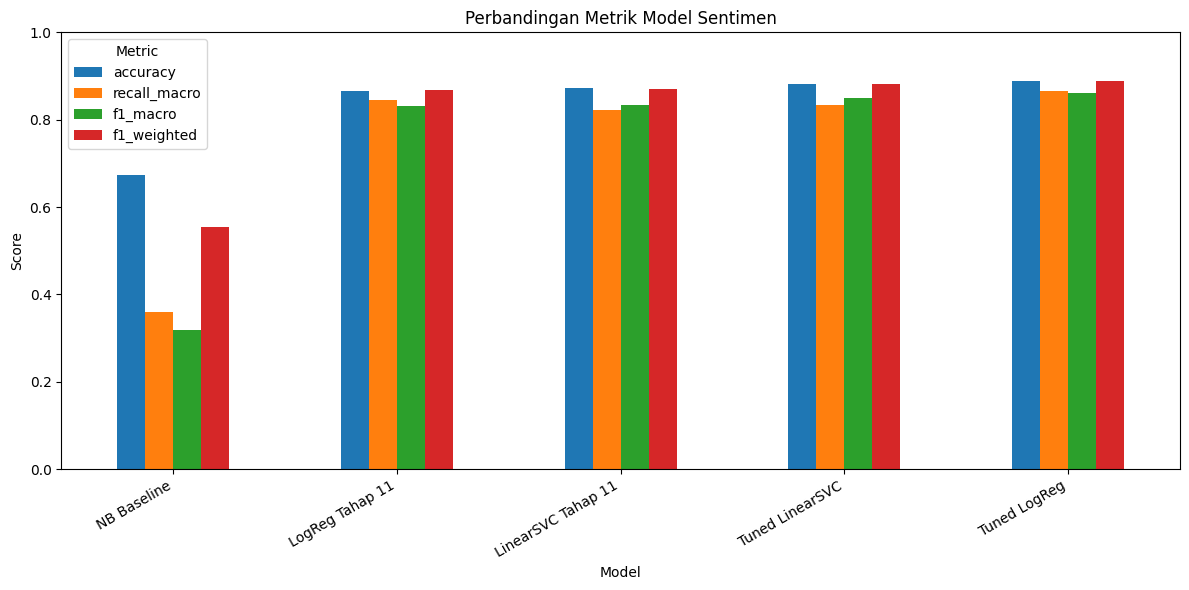

In [52]:
# ============================================================
# Visualisasi Perbandingan Metrik Utama
# ============================================================

comparison_plot_metrics = [
    "accuracy",
    "recall_macro",
    "f1_macro",
    "f1_weighted"
]

df_plot_comparison = df_model_comparison.copy()
df_plot_comparison["model_short"] = df_plot_comparison["model"].replace({
    "Baseline - TF-IDF + Multinomial Naive Bayes": "NB Baseline",
    "Improvement - TF-IDF + Logistic Regression Balanced": "LogReg Tahap 11",
    "Improvement - TF-IDF + LinearSVC": "LinearSVC Tahap 11",
    "Tuned TF-IDF + LinearSVC": "Tuned LinearSVC",
    "Tuned TF-IDF + Logistic Regression Balanced": "Tuned LogReg"
})

df_plot_ready = df_plot_comparison.set_index("model_short")[comparison_plot_metrics]

fig, ax = plt.subplots(figsize=(12, 6))
df_plot_ready.plot(kind="bar", ax=ax)

plt.title("Perbandingan Metrik Model Sentimen")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

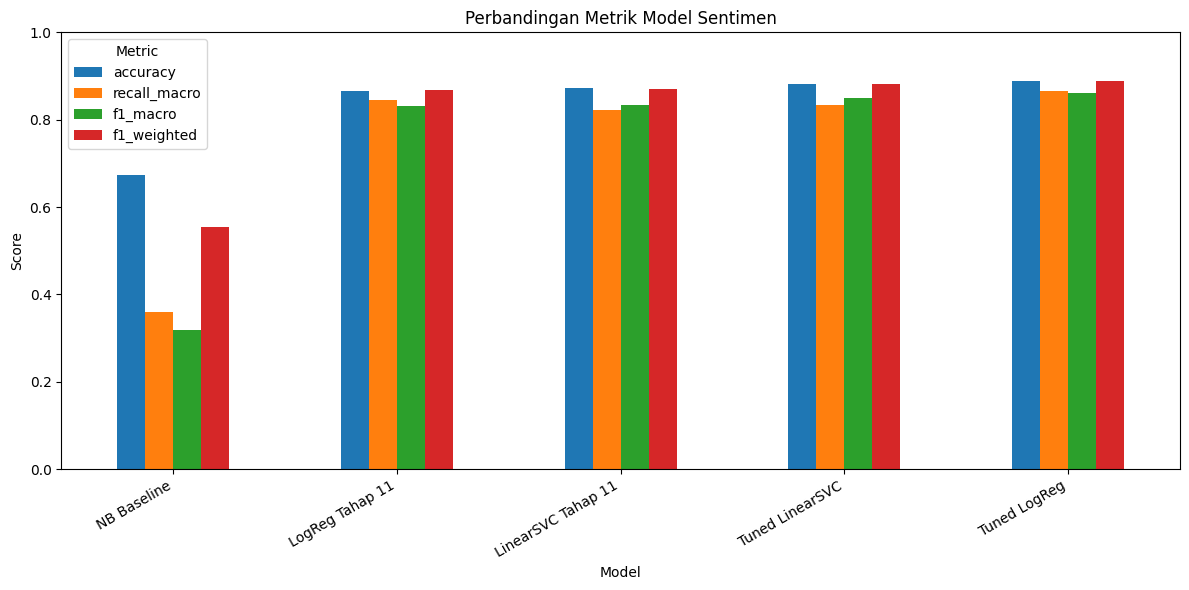

Visualisasi perbandingan metrik berhasil disimpan.
Lokasi file:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\figures\stage_12_model_metric_comparison_20260531_000426.png


In [53]:
# ============================================================
# Simpan Visualisasi Perbandingan Metrik
# ============================================================

if "timestamp" not in globals():
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

model_comparison_plot_path = (
    FIGURES_DIR / f"stage_12_model_metric_comparison_{timestamp}.png"
)

fig, ax = plt.subplots(figsize=(12, 6))
df_plot_ready.plot(kind="bar", ax=ax)

plt.title("Perbandingan Metrik Model Sentimen")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(model_comparison_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Visualisasi perbandingan metrik berhasil disimpan.")
print("Lokasi file:")
print(model_comparison_plot_path)

In [54]:
# ============================================================
# Simpan Tabel Perbandingan dan Seleksi Model Final
# ============================================================

model_comparison_path = (
    REPORTS_DIR / f"stage_12_model_comparison_{timestamp}.csv"
)

final_selection_path = (
    REPORTS_DIR / f"stage_12_final_model_selection_{timestamp}.csv"
)

class_performance_path = (
    REPORTS_DIR / f"stage_12_class_performance_negatif_positif_{timestamp}.csv"
)

df_model_comparison_rounded.to_csv(
    model_comparison_path,
    index=False,
    encoding="utf-8-sig"
)

df_final_selection_display.to_csv(
    final_selection_path,
    index=False,
    encoding="utf-8-sig"
)

df_class_performance_display.to_csv(
    class_performance_path,
    index=False,
    encoding="utf-8-sig"
)

print("Tabel perbandingan model berhasil disimpan:")
print(model_comparison_path)

print("\nTabel seleksi model final berhasil disimpan:")
print(final_selection_path)

print("\nTabel performa kelas negatif dan positif berhasil disimpan:")
print(class_performance_path)

Tabel perbandingan model berhasil disimpan:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\stage_12_model_comparison_20260531_000426.csv

Tabel seleksi model final berhasil disimpan:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\stage_12_final_model_selection_20260531_000426.csv

Tabel performa kelas negatif dan positif berhasil disimpan:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\stage_12_class_performance_negatif_positif_20260531_000426.csv


In [55]:
# ============================================================
# Simpan Ringkasan Model Final dalam Format JSON
# ============================================================

final_model_row = df_final_selection.iloc[0].to_dict()

final_model_summary = {
    "stage": "12_model_tuning_and_finalization",
    "final_model": final_model_name,
    "selection_priority": [
        "f1_macro",
        "recall_macro",
        "avg_negatif_positif_f1",
        "f1_weighted"
    ],
    "final_model_metrics": {
        key: round(float(value), 4)
        for key, value in final_model_row.items()
        if key != "model"
    },
    "artifact_saved": False,
    "artifact_note": (
        "Model artifact belum disimpan karena pipeline TF-IDF memuat vocabulary teks. "
        "Penyimpanan artifact akan dipertimbangkan pada tahap deployment lokal."
    ),
    "created_at": timestamp
}

final_model_summary_path = (
    REPORTS_DIR / f"stage_12_final_model_summary_{timestamp}.json"
)

with open(final_model_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_model_summary, f, indent=4, ensure_ascii=False)

print("Ringkasan model final berhasil disimpan.")
print("Lokasi file:")
print(final_model_summary_path)

Ringkasan model final berhasil disimpan.
Lokasi file:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\stage_12_final_model_summary_20260531_000426.json


## 11. Interpretasi Pemilihan Model Final

Berdasarkan hasil perbandingan model, model final dipilih dengan mempertimbangkan F1 Macro sebagai prioritas utama. Metrik ini digunakan karena mampu menggambarkan keseimbangan performa model pada seluruh kelas sentimen.

Selain F1 Macro, Recall Macro juga diperhatikan untuk melihat kemampuan model dalam menangkap masing-masing kelas. Performa kelas `negatif` dan `positif` juga menjadi pertimbangan penting karena kedua kelas tersebut merepresentasikan kecenderungan opini yang lebih eksplisit terhadap isu pelemahan rupiah dan persepsi daya beli masyarakat.

Model dengan nilai terbaik berdasarkan urutan prioritas tersebut dipilih sebagai model final sementara untuk project ini. Namun, artifact model belum disimpan pada tahap ini karena pipeline TF-IDF masih memuat vocabulary teks. Penyimpanan artifact akan dilakukan secara lokal pada tahap deployment, dengan tetap memperhatikan keamanan data dan batasan publikasi ke GitHub.

## 12. Evaluasi Model Final

Setelah proses tuning dan perbandingan model selesai, model terbaik dipilih sebagai model final berdasarkan prioritas metrik berikut:

1. F1 Macro
2. Recall Macro
3. Performa kelas `negatif` dan `positif`
4. F1 Weighted

Pada bagian ini, model final akan dievaluasi kembali menggunakan classification report dan confusion matrix.

Evaluasi ini bertujuan untuk memastikan bahwa model final tidak hanya memiliki accuracy yang tinggi, tetapi juga mampu mengenali masing-masing kelas sentimen secara seimbang.

In [57]:
# ============================================================
# Validasi Model Final
# ============================================================

required_final_variables = [
    "final_model_name",
    "final_model",
    "final_report_df",
    "final_cm",
    "final_y_pred",
    "available_label_order"
]

missing_final_variables = [
    var_name for var_name in required_final_variables
    if var_name not in globals()
]

if missing_final_variables:
    raise NameError(
        "Variabel model final belum lengkap. "
        f"Variabel yang belum ditemukan: {missing_final_variables}. "
        "Pastikan Code Cell 46 dan Code Cell 47 sudah dijalankan."
    )

print("Model final berhasil divalidasi.")
print("Model final:", final_model_name)

Model final berhasil divalidasi.
Model final: Tuned TF-IDF + Logistic Regression Balanced


In [58]:
# ============================================================
# Classification Report Model Final
# ============================================================

final_report_display = final_report_df.copy()

numeric_cols = final_report_display.select_dtypes(include=["float64", "float32"]).columns
final_report_display[numeric_cols] = final_report_display[numeric_cols].round(4)

print("Classification Report - Model Final:")
print("Model final:", final_model_name)

display(final_report_display)

Classification Report - Model Final:
Model final: Tuned TF-IDF + Logistic Regression Balanced


,precision,recall,f1-score,support
negatif,0.7970,0.8346,0.8154,127.0000
netral,0.9245,0.9112,0.9178,484.0000
positif,0.8455,0.8525,0.8490,122.0000
accuracy,0.8881,0.8881,0.8881,0.8881
macro avg,0.8557,0.8661,0.8607,733.0000
weighted avg,0.8893,0.8881,0.8886,733.0000


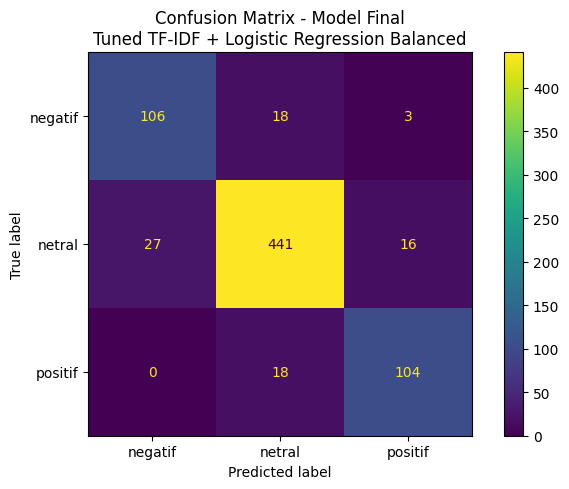

In [59]:
# ============================================================
# Confusion Matrix Model Final
# ============================================================

disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=available_label_order
)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, values_format="d")
plt.title(f"Confusion Matrix - Model Final\n{final_model_name}")
plt.tight_layout()
plt.show()

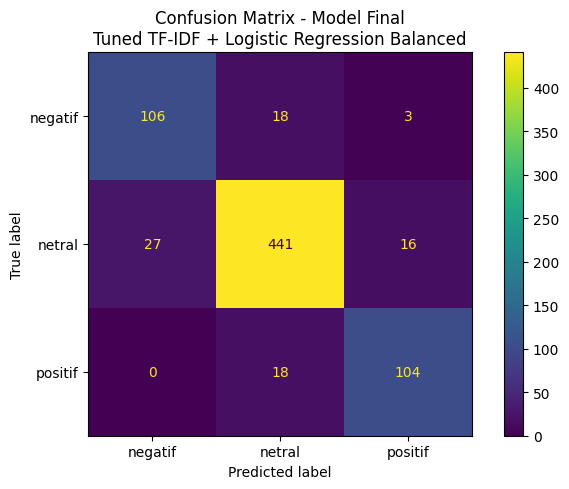

Confusion matrix model final berhasil disimpan.
Lokasi file:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\figures\stage_12_confusion_matrix_final_model_20260531_000426.png


In [60]:
# ============================================================
# Simpan Confusion Matrix Model Final
# ============================================================

final_cm_path = FIGURES_DIR / f"stage_12_confusion_matrix_final_model_{timestamp}.png"

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=available_label_order
)
disp.plot(ax=ax, values_format="d")
plt.title(f"Confusion Matrix - Model Final\n{final_model_name}")
plt.tight_layout()
plt.savefig(final_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Confusion matrix model final berhasil disimpan.")
print("Lokasi file:")
print(final_cm_path)

In [61]:
# ============================================================
# Simpan Classification Report Model Final
# ============================================================

final_classification_report_path = (
    REPORTS_DIR / f"stage_12_final_classification_report_{timestamp}.csv"
)

final_report_display.to_csv(
    final_classification_report_path,
    encoding="utf-8-sig"
)

print("Classification report model final berhasil disimpan.")
print("Lokasi file:")
print(final_classification_report_path)

Classification report model final berhasil disimpan.
Lokasi file:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\stage_12_final_classification_report_20260531_000426.csv


In [62]:
# ============================================================
# Ringkasan Metrik Model Final
# ============================================================

final_model_metrics_row = df_final_selection[
    df_final_selection["model"] == final_model_name
].iloc[0].to_dict()

df_final_metrics_summary = pd.DataFrame([final_model_metrics_row])

numeric_cols = df_final_metrics_summary.select_dtypes(include=["float64", "float32"]).columns
df_final_metrics_summary[numeric_cols] = df_final_metrics_summary[numeric_cols].round(4)

print("Ringkasan metrik model final:")
display(df_final_metrics_summary)

Ringkasan metrik model final:


,model,f1_macro,recall_macro,negatif_f1,positif_f1,avg_negatif_positif_f1,negatif_recall,positif_recall,avg_negatif_positif_recall,f1_weighted,accuracy
0,Tuned TF-IDF + Logistic Regression Balanced,0.8607,0.8661,0.8154,0.849,0.8322,0.8346,0.8525,0.8436,0.8886,0.8881


In [63]:
# ============================================================
# Interpretasi Otomatis Model Final
# ============================================================

final_f1_macro = final_model_metrics_row["f1_macro"]
final_recall_macro = final_model_metrics_row["recall_macro"]
final_f1_weighted = final_model_metrics_row["f1_weighted"]
final_accuracy = final_model_metrics_row["accuracy"]

negatif_f1 = final_model_metrics_row["negatif_f1"]
positif_f1 = final_model_metrics_row["positif_f1"]
negatif_recall = final_model_metrics_row["negatif_recall"]
positif_recall = final_model_metrics_row["positif_recall"]

interpretation_text = f"""
Model final yang dipilih adalah {final_model_name}.

Model ini memperoleh nilai accuracy sebesar {final_accuracy:.4f}, F1 Macro sebesar {final_f1_macro:.4f},
Recall Macro sebesar {final_recall_macro:.4f}, dan F1 Weighted sebesar {final_f1_weighted:.4f}.

Nilai F1 Macro digunakan sebagai pertimbangan utama karena project ini merupakan klasifikasi sentimen
multi-kelas. Dengan F1 Macro, performa model dinilai secara lebih seimbang terhadap kelas negatif,
netral, dan positif.

Pada kelas negatif, model memperoleh F1-score sebesar {negatif_f1:.4f} dan recall sebesar {negatif_recall:.4f}.
Pada kelas positif, model memperoleh F1-score sebesar {positif_f1:.4f} dan recall sebesar {positif_recall:.4f}.

Hasil ini menunjukkan bahwa model final memiliki kemampuan yang cukup baik dalam membedakan sentimen,
terutama setelah dilakukan tuning sederhana terhadap parameter TF-IDF dan parameter model klasifikasi.
"""

print(interpretation_text)


Model final yang dipilih adalah Tuned TF-IDF + Logistic Regression Balanced.

Model ini memperoleh nilai accuracy sebesar 0.8881, F1 Macro sebesar 0.8607,
Recall Macro sebesar 0.8661, dan F1 Weighted sebesar 0.8886.

Nilai F1 Macro digunakan sebagai pertimbangan utama karena project ini merupakan klasifikasi sentimen
multi-kelas. Dengan F1 Macro, performa model dinilai secara lebih seimbang terhadap kelas negatif,
netral, dan positif.

Pada kelas negatif, model memperoleh F1-score sebesar 0.8154 dan recall sebesar 0.8346.
Pada kelas positif, model memperoleh F1-score sebesar 0.8490 dan recall sebesar 0.8525.

Hasil ini menunjukkan bahwa model final memiliki kemampuan yang cukup baik dalam membedakan sentimen,
terutama setelah dilakukan tuning sederhana terhadap parameter TF-IDF dan parameter model klasifikasi.



## 13. Interpretasi Akademik Model Final

Berdasarkan hasil tuning dan perbandingan model, model final dipilih berdasarkan prioritas F1 Macro, Recall Macro, performa kelas `negatif` dan `positif`, serta F1 Weighted.

Model final menunjukkan performa yang lebih baik dibandingkan baseline Naive Bayes. Hal ini menunjukkan bahwa pendekatan tuning sederhana pada kombinasi TF-IDF dan model klasifikasi mampu meningkatkan kualitas prediksi sentimen.

Secara umum, peningkatan performa terjadi karena parameter TF-IDF yang lebih sesuai dapat membantu model menangkap pola kata yang lebih informatif. Selain itu, penggunaan model klasifikasi linear seperti LinearSVC atau Logistic Regression Balanced cukup relevan untuk data teks karena representasi TF-IDF umumnya menghasilkan fitur berdimensi tinggi dan sparse.

Dari sisi evaluasi, F1 Macro menjadi metrik utama karena dataset memiliki tiga kelas sentimen. Metrik ini lebih adil dibandingkan accuracy saja, karena memperhitungkan performa rata-rata pada setiap kelas tanpa terlalu dipengaruhi oleh kelas mayoritas.

Performa kelas `negatif` dan `positif` menjadi perhatian penting karena kedua kelas tersebut merepresentasikan opini yang lebih eksplisit terhadap isu pelemahan nilai rupiah dan persepsi daya beli masyarakat. Apabila model mampu mengenali kedua kelas tersebut dengan baik, maka model dapat digunakan sebagai dasar analisis sentimen yang lebih bermakna.

Walaupun hasil model final sudah cukup baik, model ini tetap memiliki keterbatasan. Label yang digunakan merupakan pseudo-label atau label hasil proses sebelumnya, sehingga kualitas model sangat bergantung pada kualitas label awal. Selain itu, model berbasis TF-IDF belum memahami konteks bahasa secara mendalam seperti sarkasme, ironi, atau kalimat ambigu.

Dengan demikian, model final pada tahap ini dapat digunakan sebagai kandidat utama untuk tahap deployment lokal dan visualisasi Streamlit, namun tetap perlu disertai catatan bahwa hasil prediksi bersifat analitis dan bukan representasi mutlak dari opini masyarakat.

In [64]:
# ============================================================
# Membuat Laporan Ringkasan Finalisasi Model
# ============================================================

final_report_text = f"""
# Laporan Ringkasan Tahap 12 — Tuning Sederhana dan Finalisasi Model Sentimen

## 1. Tujuan

Tahap ini bertujuan untuk melakukan tuning sederhana terhadap model klasifikasi sentimen berbasis TF-IDF.
Model yang diuji adalah LinearSVC dan Logistic Regression Balanced.

## 2. Dataset

Dataset modeling dibaca dari folder data/modeling/.

Nama file dataset:
{latest_dataset_file.name}

Jumlah data setelah validasi:
{len(df_work)} baris

Kolom fitur teks:
{TEXT_COL}

Kolom target:
{TARGET_COL}

## 3. Model yang Dibandingkan

Model yang dibandingkan meliputi:

1. Baseline TF-IDF + Multinomial Naive Bayes
2. TF-IDF + Logistic Regression Balanced Tahap 11
3. TF-IDF + LinearSVC Tahap 11
4. Tuned TF-IDF + LinearSVC
5. Tuned TF-IDF + Logistic Regression Balanced

## 4. Model Final

Model final terpilih:

{final_model_name}

## 5. Metrik Model Final

Accuracy: {final_accuracy:.4f}  
F1 Macro: {final_f1_macro:.4f}  
Recall Macro: {final_recall_macro:.4f}  
F1 Weighted: {final_f1_weighted:.4f}  

F1-score kelas negatif: {negatif_f1:.4f}  
Recall kelas negatif: {negatif_recall:.4f}  

F1-score kelas positif: {positif_f1:.4f}  
Recall kelas positif: {positif_recall:.4f}  

## 6. Interpretasi

Model final dipilih karena memiliki performa terbaik berdasarkan prioritas F1 Macro, Recall Macro,
performa kelas negatif dan positif, serta F1 Weighted.

Hasil tuning menunjukkan bahwa pendekatan TF-IDF dengan model klasifikasi linear mampu memberikan
performa yang baik untuk klasifikasi sentimen komentar YouTube terkait isu pelemahan nilai rupiah.

## 7. Catatan Keamanan

Model artifact belum disimpan pada tahap ini karena pipeline TF-IDF memuat vocabulary teks.
Penyimpanan artifact akan dipertimbangkan pada tahap deployment lokal dengan tetap menjaga keamanan data.
"""

final_report_path = REPORTS_DIR / f"stage_12_model_finalization_report_{timestamp}.md"

with open(final_report_path, "w", encoding="utf-8") as f:
    f.write(final_report_text)

print("Laporan ringkasan finalisasi model berhasil disimpan.")
print("Lokasi file:")
print(final_report_path)

Laporan ringkasan finalisasi model berhasil disimpan.
Lokasi file:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\stage_12_model_finalization_report_20260531_000426.md


In [65]:
# ============================================================
# Pemeriksaan File Sensitif Sebelum GitHub
# ============================================================

sensitive_paths_to_check = [
    PROJECT_ROOT / ".env",
    PROJECT_ROOT / "data" / "raw",
    PROJECT_ROOT / "data" / "processed",
    PROJECT_ROOT / "data" / "labeled",
    PROJECT_ROOT / "data" / "modeling",
    PROJECT_ROOT / "models",
    PROJECT_ROOT / "artifacts",
    PROJECT_ROOT / "model_artifacts"
]

print("Pemeriksaan keberadaan file/folder sensitif di project lokal:")
print("=" * 80)

for path in sensitive_paths_to_check:
    status = "ADA DI LOKAL" if path.exists() else "TIDAK DITEMUKAN"
    print(f"{status}: {path}")

print("\nCatatan:")
print("File/folder di atas boleh ada di lokal, tetapi harus dipastikan masuk ke .gitignore jika bersifat sensitif.")

Pemeriksaan keberadaan file/folder sensitif di project lokal:
ADA DI LOKAL: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\.env
ADA DI LOKAL: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\raw
ADA DI LOKAL: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\processed
ADA DI LOKAL: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\labeled
ADA DI LOKAL: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\data\modeling
ADA DI LOKAL: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\models
TIDAK DITEMUKAN: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\artifacts
TIDAK DITEMUKAN: D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\model_artifacts

Catatan:
File/folder di atas boleh ada di lokal, tetapi harus dipastikan masuk ke .gitignore jika bersifat

In [66]:
# ============================================================
# Rekomendasi Isi .gitignore
# ============================================================

recommended_gitignore = """
# Environment
.env
*.env

# Data folders
data/raw/
data/processed/
data/labeled/
data/modeling/

# Model artifacts
models/
artifacts/
model_artifacts/
*.pkl
*.joblib
*.pickle

# Jupyter
.ipynb_checkpoints/

# Python cache
__pycache__/
*.pyc

# OS files
.DS_Store
Thumbs.db
"""

print("Rekomendasi isi .gitignore:")
print(recommended_gitignore)

Rekomendasi isi .gitignore:

# Environment
.env
*.env

# Data folders
data/raw/
data/processed/
data/labeled/
data/modeling/

# Model artifacts
models/
artifacts/
model_artifacts/
*.pkl
*.joblib
*.pickle

# Jupyter
.ipynb_checkpoints/

# Python cache
__pycache__/
*.pyc

# OS files
.DS_Store
Thumbs.db



In [67]:
# ============================================================
# Rekomendasi Isi .gitignore
# ============================================================

recommended_gitignore = """
# Environment
.env
*.env

# Data folders
data/raw/
data/processed/
data/labeled/
data/modeling/

# Model artifacts
models/
artifacts/
model_artifacts/
*.pkl
*.joblib
*.pickle

# Jupyter
.ipynb_checkpoints/

# Python cache
__pycache__/
*.pyc

# OS files
.DS_Store
Thumbs.db
"""

print("Rekomendasi isi .gitignore:")
print(recommended_gitignore)

Rekomendasi isi .gitignore:

# Environment
.env
*.env

# Data folders
data/raw/
data/processed/
data/labeled/
data/modeling/

# Model artifacts
models/
artifacts/
model_artifacts/
*.pkl
*.joblib
*.pickle

# Jupyter
.ipynb_checkpoints/

# Python cache
__pycache__/
*.pyc

# OS files
.DS_Store
Thumbs.db



In [68]:
# ============================================================
# Simpan Checklist Keamanan
# ============================================================

security_checklist_text = f"""
# Checklist Keamanan GitHub — Tahap 12

## File yang boleh dipush

- Notebook .ipynb
- Laporan ringkasan agregat di folder reports/
- Metadata evaluasi model yang tidak memuat komentar asli
- Visualisasi agregat seperti grafik metrik dan confusion matrix
- File .gitignore
- README.md

## File yang tidak boleh dipush

- .env
- API key YouTube
- data/raw/
- data/processed/
- data/labeled/
- data/modeling/
- Dataset komentar penuh
- File yang memuat kolom author
- Model artifact yang memuat vocabulary TF-IDF
- File hasil prediksi yang berisi komentar asli secara penuh

## Catatan

Model final pada tahap ini belum disimpan sebagai artifact file.
Hal ini dilakukan karena pipeline TF-IDF memuat vocabulary teks yang berasal dari dataset komentar.

Checklist dibuat pada:
{timestamp}
"""

security_checklist_path = (
    REPORTS_DIR / f"stage_12_github_security_checklist_{timestamp}.md"
)

with open(security_checklist_path, "w", encoding="utf-8") as f:
    f.write(security_checklist_text)

print("Checklist keamanan GitHub berhasil disimpan.")
print("Lokasi file:")
print(security_checklist_path)

Checklist keamanan GitHub berhasil disimpan.
Lokasi file:
D:\DATA-KAMIL\MATKUL\SEMESTER-1\DATA MINING\youtube-rupiah-sentiment-analysis\reports\stage_12_github_security_checklist_20260531_000426.md


## 15. Kesimpulan Tahap 12

Tahap 12 telah menyelesaikan proses tuning sederhana dan finalisasi model sentimen.

Berdasarkan hasil evaluasi, tuning sederhana mampu meningkatkan performa model dibandingkan baseline Naive Bayes. Model final dipilih berdasarkan prioritas F1 Macro, Recall Macro, performa kelas `negatif` dan `positif`, serta F1 Weighted.

Model final belum disimpan sebagai artifact karena pipeline TF-IDF memuat vocabulary teks. Penyimpanan model akan dilakukan pada tahap deployment lokal atau Streamlit dengan tetap memperhatikan keamanan data.

Dengan selesainya tahap ini, project siap dilanjutkan ke tahap berikutnya, yaitu penyusunan dokumentasi hasil final dan persiapan deployment Streamlit secara lokal.